# Tema 12 · Bloque 2 (Viernes) — Circuitos, ejecución y colaboración

Los 4 retos. Cada uno trae primero **el contexto para entenderlo**, luego el código, después **la pregunta
del enunciado** y finalmente **la respuesta**.

**Ejecuta la celda de abajo primero** (instala lo necesario).


In [1]:
try:
    import qiskit, qiskit_aer
except ModuleNotFoundError:
    import subprocess, sys
    print("Instalando...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "qiskit", "qiskit-aer"], check=True)
    import qiskit, qiskit_aer

import matplotlib.pyplot as plt
print("Qiskit", qiskit.__version__, "· Aer", qiskit_aer.__version__)


Qiskit 2.5.2 · Aer 0.17.2


---
# RETO 1 — El estado de Bell

## 🧠 Entiende esto primero

**Qué vamos a construir:** el circuito más famoso de la computación cuántica. Solo dos compuertas, y produce
entrelazamiento.

**Las piezas:**

- **Registro cuántico** = cuántos qubits tienes. Aquí, 2.
- **Registro clásico** = dónde se anotan los resultados al medir. Aquí, 2 bits.
- **H (Hadamard)** = pone un qubit en **superposición**: deja de ser 0 o 1 y pasa a ser los dos a la vez.
- **CNOT (o CX)** = compuerta de dos qubits. Regla: *si el control vale 1, voltea el objetivo; si vale 0, no
  hace nada*. Es la que crea entrelazamiento.

**Qué hace el circuito:** `H` en el qubit 0, luego `CNOT` del 0 al 1, y medir ambos 1024 veces.

**Qué deberíamos ver:** solo `00` y `11`, mitad y mitad. Nunca `01` ni `10`. Si aparecieran en un simulador
ideal, sería un error del circuito.


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def construir_estado_bell():
    qc = QuantumCircuit(2, 2)     # 2 qubits + 2 bits clásicos
    qc.h(0)                       # superposición en el qubit 0
    qc.cx(0, 1)                   # entrelazamiento: 0 controla a 1
    qc.measure([0, 1], [0, 1])    # medir ambos
    return qc

qc_bell = construir_estado_bell()
print(qc_bell.draw(output="text"))

sim = AerSimulator()
counts = sim.run(qc_bell, shots=1024).result().get_counts()
print("\nDistribución ideal del estado de Bell:", counts)


     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Distribución ideal del estado de Bell: {'00': 508, '11': 516}


### Qué pasó, paso a paso

**Paso 0.** Los dos qubits empiezan en `|0⟩`. El estado es `|00⟩`.

**Paso 1 — la H.** Pone el qubit 0 en superposición. Ahora el sistema es mitad `|00⟩` y mitad `|01⟩`.
(El qubit 1 sigue en 0; recuerda que en Qiskit el qubit 0 es el dígito de la **derecha**.)

**Paso 2 — la CNOT.** Su regla: *si el control es 1, voltea el objetivo*. Se aplica a las dos mitades a la vez:

```
|00⟩ → control es 0 → no toca nada  → |00⟩
|01⟩ → control es 1 → voltea el otro → |11⟩
```

**Resultado:** mitad `|00⟩`, mitad `|11⟩`. Y ya no queda nada que pueda dar `01` o `10`.


In [3]:
# Veamos el estado ANTES de medir: qué configuraciones tienen amplitud
from qiskit.quantum_info import Statevector

qc_sin_medir = QuantumCircuit(2)
qc_sin_medir.h(0)
qc_sin_medir.cx(0, 1)

estado = Statevector(qc_sin_medir)
print("Amplitud de cada configuración:\n")
for base in ["00", "01", "10", "11"]:
    amp = estado.to_dict().get(base, 0)
    print(f"  |{base}>  amplitud = {amp.real:+.3f}   probabilidad = {abs(amp)**2:.3f}")

print("\n'01' y '10' tienen amplitud CERO -> no es que salgan poco: NO PUEDEN salir.")


Amplitud de cada configuración:

  |00>  amplitud = +0.707   probabilidad = 0.500
  |01>  amplitud = +0.000   probabilidad = 0.000
  |10>  amplitud = +0.000   probabilidad = 0.000
  |11>  amplitud = +0.707   probabilidad = 0.500

'01' y '10' tienen amplitud CERO -> no es que salgan poco: NO PUEDEN salir.


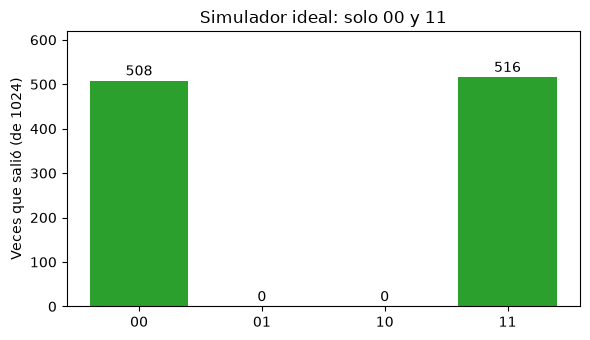

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
orden = ["00", "01", "10", "11"]
valores = [counts.get(b, 0) for b in orden]
ax.bar(orden, valores, color=["#2ca02c" if v > 0 else "#cccccc" for v in valores])
for i, v in enumerate(valores):
    ax.text(i, v + 12, str(v), ha="center", fontsize=10)
ax.set_ylabel("Veces que salió (de 1024)")
ax.set_title("Simulador ideal: solo 00 y 11")
ax.set_ylim(0, max(valores) * 1.2)
plt.tight_layout(); plt.show()


## ❓ La pregunta del reto

> **Analizando el código base, ¿por qué la combinación de H y CNOT suprime por completo los resultados "01"
> y "10" en un simulador ideal de 2 qubits?**

## ✅ Respuesta

Porque **la CNOT amarra el valor del segundo qubit al del primero**, y `01` y `10` son justo los casos donde
los dos valores son distintos.

Lo importante: no es que esos resultados salgan "poco". Es que **tienen amplitud exactamente cero**. Están
prohibidos, no son improbables.

Y la razón es que la CNOT actúa sobre **toda la superposición a la vez**. Como el control está en 0 y en 1
simultáneamente, la compuerta voltea y no voltea al mismo tiempo, y lo que queda es la mezcla `|00⟩ + |11⟩`.
Ese estado se llama **estado de Bell**, y es el ejemplo estándar de entrelazamiento.

Una comprobación útil: si midieras solo el qubit 0, saldría 0 o 1 al azar, 50/50. Ninguno de los dos tiene un
valor propio. **Lo único definido es que los dos coinciden.**


---
# RETO 2 — Cuando el hardware real no se porta bien

## 🧠 Entiende esto primero

**El escenario:** corres el mismo circuito del Reto 1, pero en una computadora cuántica de verdad. Y
aparecen resultados `01` y `10` — los que en teoría son **imposibles**. Entre un 2% y un 5% de las veces.

**Por qué pasa:** los qubits físicos son imperfectos. Tres culpables:

- **T1 (relajación)** — el qubit pierde energía y cae de `|1⟩` a `|0⟩` solo. **Va en una sola dirección**: un
  1 se convierte en 0, pero un 0 nunca sube a 1 por su cuenta.
- **T2 (decoherencia)** — el qubit pierde la *fase*, o sea la información de la superposición. Destruye el
  entrelazamiento aunque los valores parezcan bien.
- **Error de lectura** — el detector se equivoca al leer el qubit al final. También es asimétrico, por la
  misma razón: si el qubit decae durante la medición, ese 1 se lee como 0.

**Lo que vamos a hacer:** simular ese hardware imperfecto en local, con un modelo de ruido que incluye
un error de lectura **asimétrico** (confundir un 1 con un 0 es más probable que al revés). Así reproducimos
el fenómeno sin necesitar una QPU.

**Fíjate en dos cosas al ver los resultados:** cuántos `01` y `10` aparecen, y si `00` y `11` salen parejos
o no.


In [5]:
# Simulamos un hardware realista: mismo circuito, pero con ruido
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error

ruido = NoiseModel()

# 1) Error en las compuertas (hace aparecer 01 y 10)
ruido.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ["cx"])
ruido.add_all_qubit_quantum_error(depolarizing_error(0.005, 1), ["h"])

# 2) Error de lectura ASIMÉTRICO: confundir un 1 con un 0 es más probable que al revés
#    (esto es lo que pasa de verdad: el qubit decae de |1> a |0> por relajación T1)
lectura = ReadoutError([[0.98, 0.02],    # preparado 0 -> se lee 0 el 98%
                        [0.07, 0.93]])   # preparado 1 -> se lee 0 el 7%  <- fuga
ruido.add_all_qubit_readout_error(lectura)

sim_ruido = AerSimulator(noise_model=ruido)
counts_ruido = sim_ruido.run(qc_bell, shots=4096, seed_simulator=42).result().get_counts()

print("Con ruido (4096 shots):", counts_ruido)


Con ruido (4096 shots): {'01': 189, '10': 209, '00': 1932, '11': 1766}


In [6]:
# Comparación lado a lado
counts_ideal = sim.run(qc_bell, shots=4096, seed_simulator=42).result().get_counts()

print(f"{'Estado':<10}{'Ideal':>10}{'Con ruido':>12}{'':>4}Lectura")
print("-" * 70)
notas = {
    "00": "debería salir ~50%",
    "01": "PROHIBIDO en teoría",
    "10": "PROHIBIDO en teoría",
    "11": "debería salir ~50%",
}
for b in ["00", "01", "10", "11"]:
    i = counts_ideal.get(b, 0)
    r = counts_ruido.get(b, 0)
    print(f"|{b}>{'':<6}{i:>10}{r:>12}    {notas[b]}")

n00, n11 = counts_ruido.get("00", 0), counts_ruido.get("11", 0)
fuga = counts_ruido.get("01", 0) + counts_ruido.get("10", 0)
print(f"\nFuga hacia estados prohibidos: {fuga} de 4096  ({fuga/4096*100:.1f}%)")
print(f"Asimetría 00 vs 11           : {n00} vs {n11}  ->  {(n00-n11)/(n00+n11)*100:+.1f}%")
print("\n>>> Sale MÁS '00' que '11'. Esa es la pista del diagnóstico.")


Estado         Ideal   Con ruido    Lectura
----------------------------------------------------------------------
|00>            2009        1932    debería salir ~50%
|01>               0         189    PROHIBIDO en teoría
|10>               0         209    PROHIBIDO en teoría
|11>            2087        1766    debería salir ~50%

Fuga hacia estados prohibidos: 398 de 4096  (9.7%)
Asimetría 00 vs 11           : 1932 vs 1766  ->  +4.5%

>>> Sale MÁS '00' que '11'. Esa es la pista del diagnóstico.


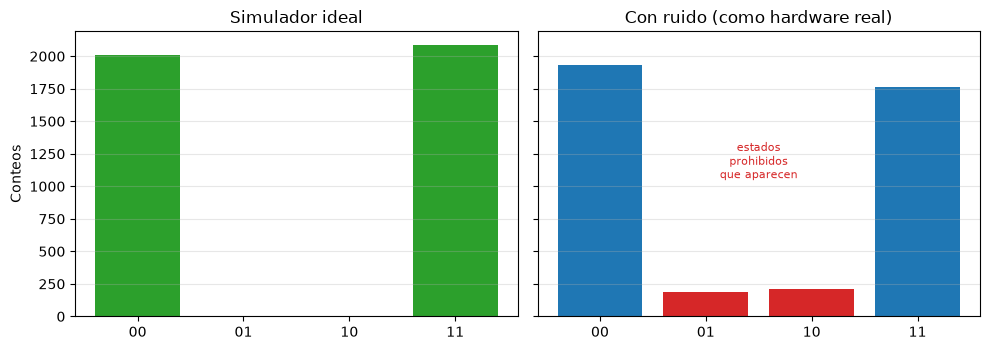

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
orden = ["00", "01", "10", "11"]

a1.bar(orden, [counts_ideal.get(b, 0) for b in orden], color="#2ca02c")
a1.set_title("Simulador ideal"); a1.set_ylabel("Conteos")

a2.bar(orden, [counts_ruido.get(b, 0) for b in orden],
       color=["#1f77b4", "#d62728", "#d62728", "#1f77b4"])
a2.set_title("Con ruido (como hardware real)")
a2.text(1.5, max(counts_ruido.values()) * 0.55, "estados\nprohibidos\nque aparecen",
        ha="center", color="#d62728", fontsize=8)

for ax in (a1, a2):
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


### Los tres culpables (glosario rápido)

**T1 — tiempo de relajación.** El qubit pierde energía y cae de `|1⟩` a `|0⟩` solo. **Va en una sola
dirección**: un 1 se convierte en 0, pero un 0 nunca sube a 1 por sí mismo.

**T2 — decoherencia.** El qubit pierde la *fase*, o sea la información de la superposición. Destruye el
entrelazamiento aunque los valores sigan bien.

**Error de lectura.** El detector se equivoca al leer el qubit al final. Y también es asimétrico, por la
misma razón: si el qubit decae durante la medición, el 1 se lee como 0.

### Fallo lógico vs. ruido

| | Fallo lógico | Ruido de hardware |
|---|---|---|
| Aparece en el simulador ideal | **Sí** | No |
| Es reproducible | Siempre igual | Varía en cada corrida |
| Magnitud | Grande, estructural | Pequeña, un 1-5% |
| Ejemplo | Pusiste `cx(1,0)` al revés | Sale 3% de `01` |

**La regla:** si el simulador ideal sale limpio y el hardware no, **no es tu código**.


## ❓ La pregunta del reto

> **Si observas una asimetría marcada en la frecuencia de ocurrencia entre "00" y "11" en hardware real,
> ¿qué diagnóstico físico puedes inferir sobre la calibración de los canales de medida de los qubits
> involucrados?**

## ✅ Respuesta

Una asimetría marcada entre `00` y `11` apunta a **error de lectura asimétrico**, causado por la
**relajación T1** de los qubits.

**El razonamiento:**

Teóricamente `00` y `11` deben salir igual, 50% cada uno. El circuito los trata de forma perfectamente
simétrica, así que **nada en la lógica puede favorecer a uno**.

Pero la física sí tiene una dirección preferida: **un qubit en `|1⟩` decae solo hacia `|0⟩`** (pierde
energía), mientras que un `|0⟩` nunca sube a `|1⟩` por su cuenta.

Entonces, si un qubit del estado `11` decae antes de ser leído, ese resultado se contamina hacia `10`, `01`
o `00`. En cambio los `00` no se degradan hacia arriba. **Resultado: se acumula exceso de `00`.**

**El diagnóstico concreto:**
- Si sale **más `00` que `11`** → relajación T1 corta y/o error de lectura sesgado hacia 0. Es lo típico.
- Si sale **más `11` que `00`** → algo raro: probablemente el umbral del discriminador de lectura está mal
  calibrado, o hay excitación térmica residual (el qubit no arranca bien en `|0⟩`).
- Si además hay mucho `01` y `10` → error en la compuerta de dos qubits (la CNOT) o pérdida de coherencia T2.

**La solución práctica:** *readout error mitigation*. Se mide primero la matriz de confusión del detector
(preparar `|0⟩` y ver cuánto se lee mal, luego `|1⟩` igual) y se corrige el histograma con esa matriz. Es la
mitigación más barata que existe y suele ser lo primero que se aplica.


---
# RETO 3 — Que tu notebook funcione igual en otra computadora

## 🧠 Entiende esto primero

**El problema:** compartes tu notebook y a tu compañero le salen números distintos. ¿Es un bug o es normal?
Sin información, **no hay forma de saberlo**. Y eso arruina cualquier revisión.

**Dos causas, muy distintas:**

- **Versiones distintas del SDK.** Tú tienes Qiskit 2.5, tu compañero 1.4. Una actualización pudo cambiar
  cómo se transpila el circuito, y el resultado cambia sin que nadie tocara el código.
- **Aleatoriedad no fijada.** Los simuladores con ruido usan números aleatorios. Sin fijar la **semilla**,
  ni siquiera **tus propias corridas** coinciden entre sí.

**Dos palabras del enunciado:**

- **CI/CD** = Integración Continua. Un servidor que corre tus pruebas automáticamente cada vez que subes
  código a GitHub, para avisarte si algo se rompió.
- **Semilla (seed)** = el número que inicializa el generador de aleatorios. Fijarla no elimina el azar: lo
  hace **repetible**.

**Lo que vamos a hacer:** una celda de metadatos, una demostración de qué pasa con y sin semilla, y una
"huella" del circuito compilado — que es exactamente lo que un test de CI compara en cada push.


In [8]:
# La cabecera que TODO notebook compartido debería tener
import sys, platform, json, datetime
import qiskit, qiskit_aer, numpy as np

metadatos = {
    "fecha_ejecucion": datetime.datetime.now().isoformat(timespec="seconds"),
    "python": sys.version.split()[0],
    "sistema": platform.system(),
    "qiskit": qiskit.__version__,
    "qiskit_aer": qiskit_aer.__version__,
    "numpy": np.__version__,
    "SEED": 42,
}

print("METADATOS DE EJECUCIÓN")
print(json.dumps(metadatos, indent=2, ensure_ascii=False))
print("\nSi alguien no reproduce tus resultados, esto le dice POR QUÉ.")


METADATOS DE EJECUCIÓN
{
  "fecha_ejecucion": "2026-09-19T04:29:00",
  "python": "3.11.15",
  "sistema": "Linux",
  "qiskit": "2.5.2",
  "qiskit_aer": "0.17.2",
  "numpy": "2.4.6",
  "SEED": 42
}

Si alguien no reproduce tus resultados, esto le dice POR QUÉ.


In [9]:
# Por qué importan las semillas
SEED = 42

print("SIN semilla (cada corrida da distinto):")
for i in range(3):
    c = sim_ruido.run(qc_bell, shots=1024).result().get_counts()
    print(f"   corrida {i+1}: 00={c.get('00',0)}  11={c.get('11',0)}")

print("\nCON semilla fija (siempre idéntico):")
for i in range(3):
    c = sim_ruido.run(qc_bell, shots=1024, seed_simulator=SEED).result().get_counts()
    print(f"   corrida {i+1}: 00={c.get('00',0)}  11={c.get('11',0)}")

print("\nLa semilla NO elimina el azar: lo hace REPETIBLE.")
print("Sin ella, un revisor nunca obtendrá tus números exactos y no sabrá si hay un bug.")


SIN semilla (cada corrida da distinto):
   corrida 1: 00=487  11=438
   corrida 2: 00=493  11=431
   corrida 3: 00=512  11=434

CON semilla fija (siempre idéntico):


   corrida 1: 00=491  11=435
   corrida 2: 00=491  11=435
   corrida 3: 00=491  11=435

La semilla NO elimina el azar: lo hace REPETIBLE.
Sin ella, un revisor nunca obtendrá tus números exactos y no sabrá si hay un bug.


In [10]:
# Un test de CI de verdad: ¿el circuito compila igual siempre?
from qiskit import transpile
from qiskit.circuit import Parameter

theta = Parameter("θ")
qc_param = QuantumCircuit(2)
qc_param.h(0)
qc_param.rz(theta, 0)     # una rotación que depende de un parámetro
qc_param.cx(0, 1)

def huella(circuito):
    # Resumen del circuito compilado: si cambia, algo cambió en el entorno.
    t = transpile(circuito, basis_gates=["cx", "rz", "sx", "x"],
                  optimization_level=1, seed_transpiler=SEED)
    return {"ops": dict(sorted(t.count_ops().items())), "profundidad": t.depth()}

h1 = huella(qc_param)
h2 = huella(qc_param)

print("Huella 1:", h1)
print("Huella 2:", h2)
print("\n¿Compila idéntico?", h1 == h2)

print("\nEsto es exactamente lo que un test de CI comprueba en cada push:")
print("  assert huella(mi_circuito) == HUELLA_ESPERADA")
print("Si falla -> una versión del SDK cambió el resultado. Te enteras el mismo día.")


Huella 1: {'ops': {'cx': 1, 'rz': 3, 'sx': 1}, 'profundidad': 5}
Huella 2: {'ops': {'cx': 1, 'rz': 3, 'sx': 1}, 'profundidad': 5}

¿Compila idéntico? True

Esto es exactamente lo que un test de CI comprueba en cada push:
  assert huella(mi_circuito) == HUELLA_ESPERADA
Si falla -> una versión del SDK cambió el resultado. Te enteras el mismo día.


## ❓ La pregunta del reto

> **¿Qué buenas prácticas de CI/CD (integración continua) o versionado en GitHub aplicarías para validar que
> un circuito cuántico parametrizado compila de forma idéntica en diferentes entornos de desarrollo?**

## ✅ Respuesta

**El problema:** el mismo notebook puede dar resultados distintos en otra máquina, porque cambió la versión
de Qiskit, la de Python, o simplemente porque el azar no estaba fijado. En una revisión por pares, eso es
indistinguible de un bug.

**Las prácticas, de más a menos importante:**

**1. Fijar versiones exactas.** Un `requirements.txt` con `qiskit==2.5.2`, no `qiskit` a secas. Así todos
instalan lo mismo. (Con `>=` cada quien acaba con una versión distinta.)

**2. Fijar todas las semillas.** `seed_simulator` para la ejecución y `seed_transpiler` para la compilación.
Sin esto, dos corridas tuyas ya difieren entre sí.

**3. Celda de metadatos al inicio.** Versiones, fecha, sistema operativo, semilla. Es el registro que explica
cualquier discrepancia futura.

**4. Tests automáticos en cada push (CI).** Un GitHub Action que corre el notebook y verifica:
- que el circuito transpilado tiene la misma huella (compuertas y profundidad),
- que la distribución de resultados cae dentro de una tolerancia esperada.

Así, si una actualización del SDK cambia el comportamiento, **te enteras el mismo día**, no meses después.

**5. Notebooks limpios en Git.** Guardar sin salidas ejecutadas (`nbstripout`), porque si no, cada corrida
genera un diff gigante e ilegible aunque no hayas tocado el código.

**6. Congelar el entorno completo.** Para trabajo serio, un Dockerfile o un `environment.yml` de Conda: fija
también el sistema operativo y las librerías de bajo nivel, no solo los paquetes de Python.

**La idea de fondo:** un resultado que no se puede reproducir **no es un resultado**. Y en cuántica el riesgo
es doble, porque ya hay aleatoriedad genuina — si además no fijas las semillas, nunca distingues el azar
legítimo de un error real.


---
# RETO 4 — Mandar trabajos a una QPU sin quedarte colgado

## 🧠 Entiende esto primero

**El escenario:** mandas tu circuito a una computadora cuántica real de IBM. No se ejecuta al instante:
entra en una **cola compartida** con usuarios de todo el mundo. Puede tardar **de segundos a horas**.

**Vocabulario:**

- **Job** = un trabajo enviado a la QPU (tu circuito + cuántos shots quieres).
- **Cola (queue)** = la fila de espera. Tu job pasa por estados: `QUEUED` → `RUNNING` → `DONE`.
- **Síncrono / bloqueante** = tu programa se **congela** esperando el resultado.
- **Asíncrono** = mandas el job, sigues con otra cosa, y consultas después.
- **Polling (sondeo)** = preguntar cada cierto tiempo "¿ya está listo?".
- **Backoff exponencial** = esperar cada vez más entre preguntas (2s, 4s, 8s, 16s...) para no saturar el
  servidor.
- **Timeout** = el tiempo máximo que esperas antes de rendirte.

**El error típico:** usar `job.result()` directamente, que bloquea el programa hasta horas. Si se corta la
red o el script muere, **pierdes la referencia al job** — aunque el job siga corriendo en el servidor y
consumiendo tu cuota.

**Lo que vamos a hacer:** comparar el patrón malo con el bueno, simular un backoff exponencial, y armar una
tabla de qué hacer según cómo falle el job.


In [11]:
# Por qué NO se debe esperar bloqueando
print("PATRÓN SÍNCRONO (malo):\n")
print("  job = backend.run(circuito)")
print("  resultado = job.result()      # <- el programa se CONGELA aquí")
print("                               #    minutos... u horas")
print("\n  Problemas:")
for p in ["El programa no puede hacer nada más mientras espera",
          "Si se corta la red, pierdes la referencia al job (que sigue corriendo)",
          "No puedes lanzar 50 circuitos en paralelo: van uno por uno",
          "Un timeout del cliente mata tu script aunque el job esté casi listo"]:
    print("   -", p)

print("\n\nPATRÓN ASÍNCRONO (bueno):\n")
print("  job = backend.run(circuito)")
print("  job_id = job.job_id()        # <- GUARDA ESTO EN DISCO")
print("  # ...el programa sigue haciendo otras cosas...")
print("  # más tarde, incluso en otra sesión:")
print("  job = service.job(job_id)    # lo recuperas por su id")


PATRÓN SÍNCRONO (malo):

  job = backend.run(circuito)
  resultado = job.result()      # <- el programa se CONGELA aquí
                               #    minutos... u horas

  Problemas:
   - El programa no puede hacer nada más mientras espera
   - Si se corta la red, pierdes la referencia al job (que sigue corriendo)
   - No puedes lanzar 50 circuitos en paralelo: van uno por uno
   - Un timeout del cliente mata tu script aunque el job esté casi listo


PATRÓN ASÍNCRONO (bueno):

  job = backend.run(circuito)
  job_id = job.job_id()        # <- GUARDA ESTO EN DISCO
  # ...el programa sigue haciendo otras cosas...
  # más tarde, incluso en otra sesión:
  job = service.job(job_id)    # lo recuperas por su id


In [12]:
# Backoff exponencial: cómo sondear sin saturar el servidor
import time

def esperar_job(estados_simulados, max_intentos=8, espera_inicial=2, tope=60):
    # Consulta el estado del job esperando cada vez más entre intentos.
    espera = espera_inicial
    registro = []
    for intento in range(1, max_intentos + 1):
        estado = estados_simulados[min(intento - 1, len(estados_simulados) - 1)]
        registro.append((intento, estado, espera))
        if estado in ("DONE", "ERROR", "CANCELLED"):
            return estado, registro
        espera = min(espera * 2, tope)     # duplicar, con tope
    return "TIMEOUT", registro

estado_final, registro = esperar_job(
    ["QUEUED", "QUEUED", "QUEUED", "RUNNING", "RUNNING", "DONE"]
)

print(f"{'Consulta':>9}{'Estado':>12}{'Espera hasta la siguiente (s)':>32}")
print("-" * 55)
for i, e, w in registro:
    print(f"{i:>9}{e:>12}{w:>32}")
print(f"\nResultado final: {estado_final}")
print("\nLa espera se duplica: 2, 4, 8, 16, 32, 60, 60...")
print("Así no bombardeas la API con miles de consultas inútiles.")


 Consulta      Estado   Espera hasta la siguiente (s)
-------------------------------------------------------
        1      QUEUED                               2
        2      QUEUED                               4
        3      QUEUED                               8
        4     RUNNING                              16
        5     RUNNING                              32
        6        DONE                              60

Resultado final: DONE

La espera se duplica: 2, 4, 8, 16, 32, 60, 60...
Así no bombardeas la API con miles de consultas inútiles.


In [13]:
# Estrategia completa: qué hacer según cómo falle el job
estrategias = [
    ("DONE",              "Guardar resultados + metadatos del backend", "—"),
    ("QUEUED / RUNNING",  "Seguir sondeando con backoff",               "—"),
    ("ERROR (transitorio)","Reintentar hasta 3 veces con backoff",      "Sí"),
    ("CANCELLED (calibración)", "Re-encolar automáticamente",           "Sí, tras esperar"),
    ("TIMEOUT del cliente","NO matar el job: guardar el id y salir",    "Recuperar luego"),
    ("ERROR persistente", "Registrar, alertar y seguir con el siguiente", "No"),
]

print(f"{'Estado del job':<28}{'Qué hacer':<46}Reintentar")
print("-" * 92)
for e, a, r in estrategias:
    print(f"{e:<28}{a:<46}{r}")

print("\n\nREGLA DE ORO: guarda el job_id EN DISCO apenas lo envías.")
print("Mientras tengas el id, puedes recuperar el resultado aunque tu script muera.")


Estado del job              Qué hacer                                     Reintentar
--------------------------------------------------------------------------------------------
DONE                        Guardar resultados + metadatos del backend    —
QUEUED / RUNNING            Seguir sondeando con backoff                  —
ERROR (transitorio)         Reintentar hasta 3 veces con backoff          Sí
CANCELLED (calibración)     Re-encolar automáticamente                    Sí, tras esperar
TIMEOUT del cliente         NO matar el job: guardar el id y salir        Recuperar luego
ERROR persistente           Registrar, alertar y seguir con el siguiente  No


REGLA DE ORO: guarda el job_id EN DISCO apenas lo envías.
Mientras tengas el id, puedes recuperar el resultado aunque tu script muera.


## ❓ La pregunta del reto

> **¿Qué estrategia de manejo de errores implementas si un job de QPU expira o falla por interrupción de
> calibración del procesador mientras tu pipeline científico está en ejecución?**

## ✅ Respuesta

**La idea central:** un job en cola puede tardar horas, así que el pipeline **nunca debe quedarse esperando**.
Se envía, se guarda el identificador, y se consulta después.

**La estrategia, por partes:**

**1. Persistir el `job_id` inmediatamente.** En cuanto envías el circuito, guardas su id en disco o en una
base de datos. Mientras tengas ese id, el resultado es recuperable **aunque tu script se caiga, se corte la
red o reinicies la máquina**. Es la única protección que realmente importa.

**2. Distinguir el tipo de fallo.** No todos merecen la misma reacción:
- **Transitorio** (red caída, servidor saturado) → reintentar con backoff exponencial.
- **Calibración del procesador** → el job se cancela solo; hay que **re-encolarlo**, idealmente esperando a
  que termine la recalibración o mandándolo a otro backend.
- **Permanente** (circuito inválido, sin permisos) → no reintentar nunca. Reintentar un error lógico solo
  gasta cuota.

**3. Backoff exponencial con tope.** Consultar cada 2, 4, 8, 16... segundos hasta un máximo. Consultar cada
segundo durante horas satura la API y puede hacer que te limiten el acceso.

**4. Checkpoints por circuito.** Si mandas 50 circuitos, guarda cada resultado en cuanto llega. Si algo falla
en el número 47, no repites los 46 anteriores.

**5. Idempotencia.** Etiquetar cada job (`tags=["experimento_A", "circuito_12"]`) para poder consultar si ya
se ejecutó antes de reenviarlo. Evita pagar dos veces por lo mismo.

**6. Backend de respaldo.** Si una QPU entra en calibración, redirigir a otra con características similares —
anotando el cambio en los metadatos, porque los resultados no serán directamente comparables.

**7. Alertas.** Un pipeline que corre solo durante días necesita avisar cuando algo se atasca. Si no, te
enteras una semana después.

**En una frase:** enviar de forma asíncrona, guardar el `job_id` antes que nada, clasificar los fallos entre
transitorios y permanentes, y reintentar solo los primeros con backoff exponencial.


---
## Resumen del tema

| Concepto | Idea |
|---|---|
| **Estado de Bell** | `H` + `CNOT` = dos qubits entrelazados. Solo salen `00` y `11` |
| **Los 3 modos** | Ideal (lógica) → con ruido (ensayo) → hardware real (final) |
| **Estados prohibidos** | Si aparecen `01` o `10` en hardware, es ruido, no un bug |
| **Asimetría 00/11** | Relajación T1 + lectura sesgada: los `1` se degradan hacia `0` |
| **Reproducibilidad** | Versiones fijas + semillas + metadatos + tests en CI |
| **Jobs en cola** | Asíncrono, guardar el `job_id`, backoff exponencial |

**Preguntas de cierre del PDF:**

- *¿Cómo influye la elección del framework?* Determina a qué hardware llegas y cuánto costaría cambiar de
  proveedor. Qiskit para aprender y para IBM; Braket si necesitas varios fabricantes.

- *¿Cómo diseñar un flujo que integre simulación y hardware real?* En tres etapas: **ideal** para verificar
  que la lógica es correcta, **con ruido** para anticipar cómo se degradará (y ajustar el circuito antes de
  gastar cola), y **hardware real** solo al final, comparando contra el resultado ideal para medir cuánto se
  desvió. Esa comparación es la que justifica aplicar mitigación de errores.
